In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats

In [242]:
# Chargement et préparation des données
df = pd.read_excel("features_MF.xlsx")
print(df.shape)
df.head()

(2216, 77)


,Player,Nation,Pos,Team,Comp,Age,MP,Starts,Min,90s,...,Int,Tkl+Int,Clr,Err,Pass/90,KP/90,PrgC/90,PrgP/90,Chllngs Lost/90,Ligue_Weight
0,Brenden Aaronson,USA,MF,Leeds United,Premier League,21,36,28,2372,26.4,...,5,50,6,1,1.515152,1.742424,1.628788,3.257576,1.174242,1.5
1,Paxten Aaronson,USA,MF,Eint Frankfurt,Bundesliga,18,7,0,173,1.9,...,0,6,2,0,0.526316,0.526316,4.210526,3.157895,0.526316,1.3
2,Himad Abdelli,ALG,MF,Angers,Ligue 1,22,30,24,2137,23.7,...,28,92,15,0,1.223629,1.518987,2.447257,6.371308,1.518987,1.1
3,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,33,33,2894,32.2,...,36,82,26,0,0.900621,0.527950,1.024845,5.124224,0.714286,1.1
4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29,29,28,2342,26.0,...,34,126,39,0,1.500000,0.538462,0.500000,5.500000,2.038462,1.1


In [243]:
#Séparer les variables descriptives (l'ACP n'utilise que les variables quantitatives)
meta_cols = [
    "Player", "Nation", "Pos", "Team", "Comp", "Year"
]

In [244]:
# Nettoyage : remplacer les virgules par des points
df= df.replace(",", ".", regex=True)
df = df.apply(pd.to_numeric, errors="ignore")

C:\Users\Dell\AppData\Local\Temp\ipykernel_9356\1306616843.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [245]:
features_mid = [
    # Variables offensives / créatives
    "KP", "PrgC","PrgR", "Gls/90", "Ast/90", "xG/90", "xAG/90",
    
    # Variables défensives
    "Tkl", "TklW", "Tkl+Int", "Tkl Def 3rd", "Tkl Mid 3rd", "Blocks", "Int","Clr"
]


X = df[features_mid]
X.describe()

,KP,PrgC,PrgR,Gls/90,Ast/90,xG/90,xAG/90,Tkl,TklW,Tkl+Int,Tkl Def 3rd,Tkl Mid 3rd,Blocks,Int,Clr
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,18.634477,26.892148,52.008574,0.115041,0.107852,0.126864,0.113317,31.022563,18.175090,45.178249,12.431859,14.150271,18.600632,14.155686,18.864170
std,17.300008,24.529314,50.342775,0.169261,0.168805,0.116524,0.094881,22.812049,13.668505,33.499143,10.431324,10.852322,13.360458,12.293133,17.182464
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,9.000000,16.000000,0.000000,0.000000,0.050000,0.048296,13.000000,7.000000,18.000000,4.000000,5.000000,8.000000,5.000000,6.000000
50%,14.000000,20.000000,35.000000,0.070000,0.070000,0.090000,0.090909,27.000000,16.000000,39.000000,10.000000,12.000000,16.000000,11.000000,14.000000
75%,25.000000,37.000000,73.000000,0.170000,0.160000,0.170000,0.153846,44.000000,26.000000,65.000000,18.000000,21.000000,27.000000,20.000000,27.000000
max,127.000000,160.000000,316.000000,4.090000,5.000000,1.420000,0.909091,152.000000,83.000000,198.000000,80.000000,70.000000,74.000000,72.000000,109.000000


In [246]:
df_clean = df.loc[df[features_mid].dropna().index]
X = df_clean[features_mid]

print(f"\nNombre de joueurs après nettoyage: {len(df_clean)}")
print(f"\nValeurs manquantes:\n{X.isnull().sum()}")



Nombre de joueurs après nettoyage: 2216

Valeurs manquantes:
KP             0
PrgC           0
PrgR           0
Gls/90         0
Ast/90         0
xG/90          0
xAG/90         0
Tkl            0
TklW           0
Tkl+Int        0
Tkl Def 3rd    0
Tkl Mid 3rd    0
Blocks         0
Int            0
Clr            0
dtype: int64


In [247]:
# Standardisation et ACP
X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


In [248]:
# Variance expliquée
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"PC{i+1}: {var*100:.2f}%")
print(f"Cumul PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

PC1: 48.78%
PC2: 21.83%
PC3: 7.55%
PC4: 6.54%
PC5: 3.03%
Cumul PC1+PC2: 70.61%


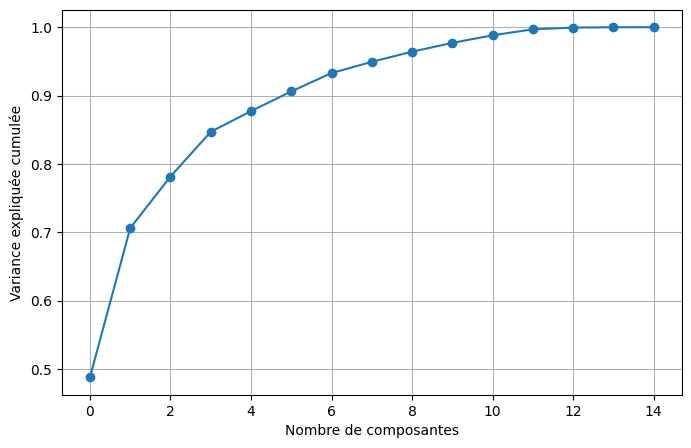

In [249]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.grid()
plt.show()


In [250]:
#Exploration des axes
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca2.components_.T,
    index=features_mid,
    columns=["PC1", "PC2"]
)

print("\nCONTRIBUTIONS PC1")
print(loadings.sort_values("PC1", ascending=False))

print("\nCONTRIBUTIONS PC2")
print(loadings.sort_values("PC2", ascending=False))


CONTRIBUTIONS PC1
                  PC1       PC2
Tkl+Int      0.364051 -0.046287
Tkl          0.359934 -0.026363
TklW         0.354016 -0.026296
Tkl Mid 3rd  0.343378 -0.030178
Tkl Def 3rd  0.336985 -0.082115
Blocks       0.334613  0.032847
Int          0.324129 -0.077214
Clr          0.295649 -0.112130
KP           0.181736  0.394622
PrgC         0.152813  0.401273
PrgR         0.104291  0.451895
Ast/90      -0.019912  0.292288
Gls/90      -0.033852  0.294178
xAG/90      -0.041692  0.397976
xG/90       -0.078416  0.343351

CONTRIBUTIONS PC2
                  PC1       PC2
PrgR         0.104291  0.451895
PrgC         0.152813  0.401273
xAG/90      -0.041692  0.397976
KP           0.181736  0.394622
xG/90       -0.078416  0.343351
Gls/90      -0.033852  0.294178
Ast/90      -0.019912  0.292288
Blocks       0.334613  0.032847
TklW         0.354016 -0.026296
Tkl          0.359934 -0.026363
Tkl Mid 3rd  0.343378 -0.030178
Tkl+Int      0.364051 -0.046287
Int          0.324129 -0.077214
Tk

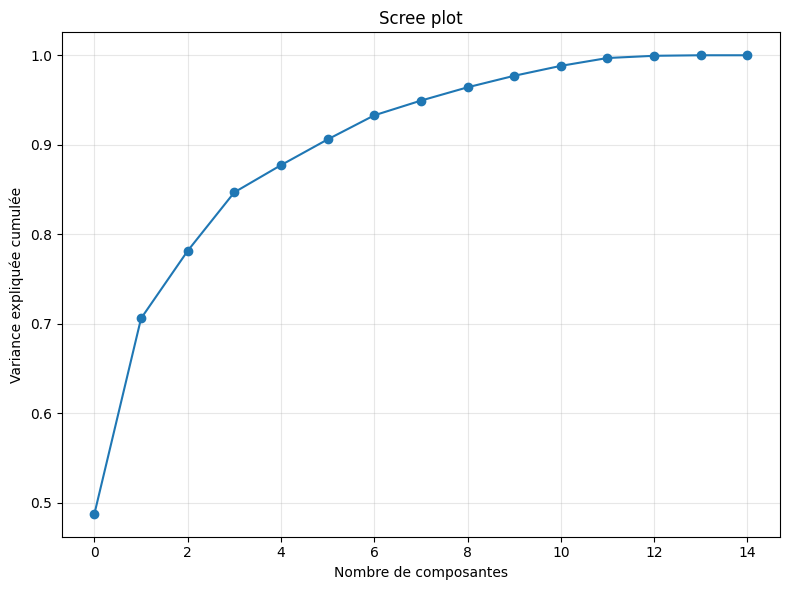

In [251]:
#Variance expliquée cumulée
plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Scree plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 2000x1500 with 0 Axes>

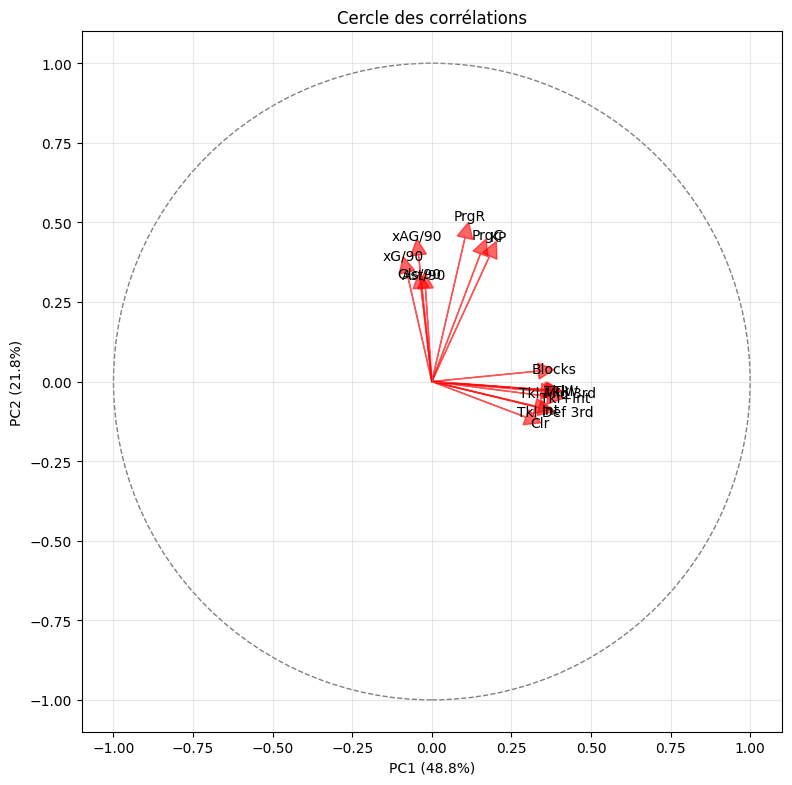

In [252]:
#Cercle des correlations
plt.figure(figsize=(20,15))
circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
fig, ax2 = plt.subplots(figsize=(8,8))
ax2.add_artist(circle)

for i, var in enumerate(features_mid):
    ax2.arrow(0, 0, 
             loadings.iloc[i, 0], 
             loadings.iloc[i, 1],
             head_width=0.05, 
             head_length=0.05, 
             fc='red', 
             ec='red',
             alpha=0.6)
    ax2.text(loadings.iloc[i, 0]*1.15, 
            loadings.iloc[i, 1]*1.15, 
            var, 
            ha='center', 
            va='center',
            fontsize=10)

ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('Cercle des corrélations')
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()

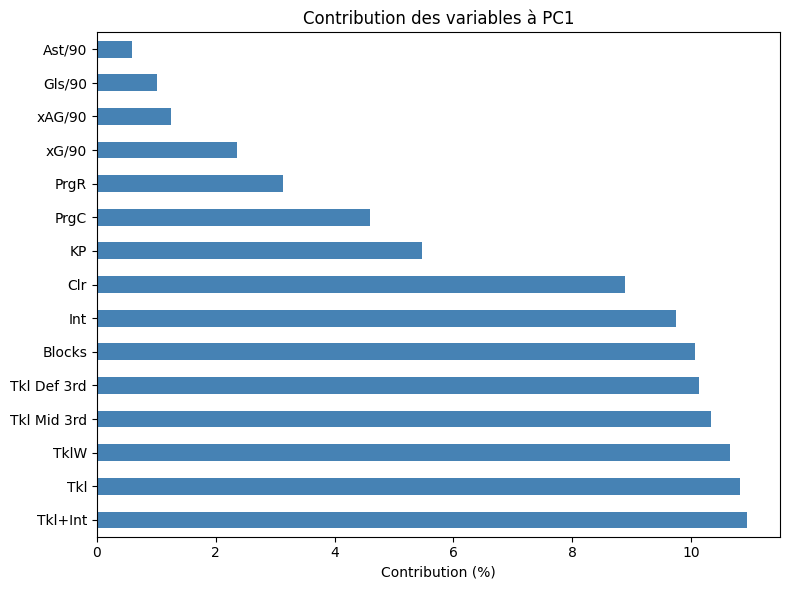

In [253]:
plt.figure(figsize=(8,6))
contrib = loadings.abs() * 100 / loadings.abs().sum()
contrib['PC1'].sort_values(ascending=False).plot(kind='barh', color='steelblue')
plt.title('Contribution des variables à PC1')
plt.xlabel('Contribution (%)')
plt.tight_layout()
plt.show()

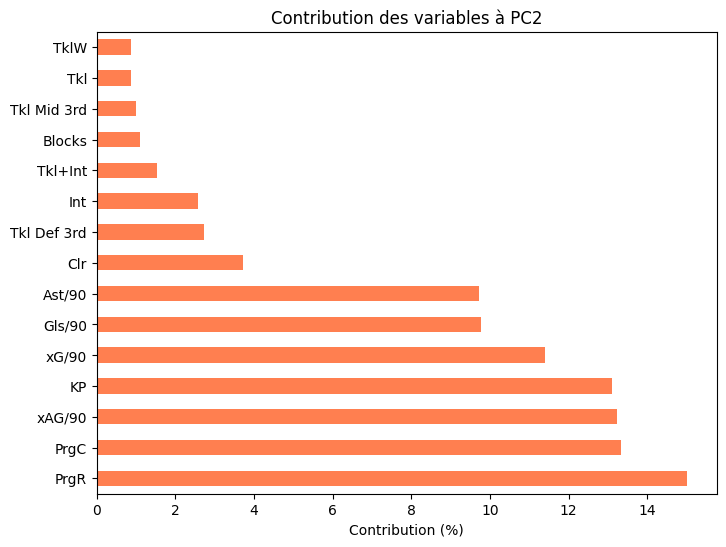

In [254]:
# 4.4 Contributions à PC2
plt.figure(figsize=(8,6))
contrib['PC2'].sort_values(ascending=False).plot(kind='barh', color='coral')
plt.title('Contribution des variables à PC2')
plt.xlabel('Contribution (%)')
plt.show()


In [255]:
df_pca = pd.DataFrame(X_pca2, columns=["PC1", "PC2"], index=df_clean.index)
df_results = df_clean.copy()
df_results["PC1"] = df_pca["PC1"]
df_results["PC2"] = df_pca["PC2"]

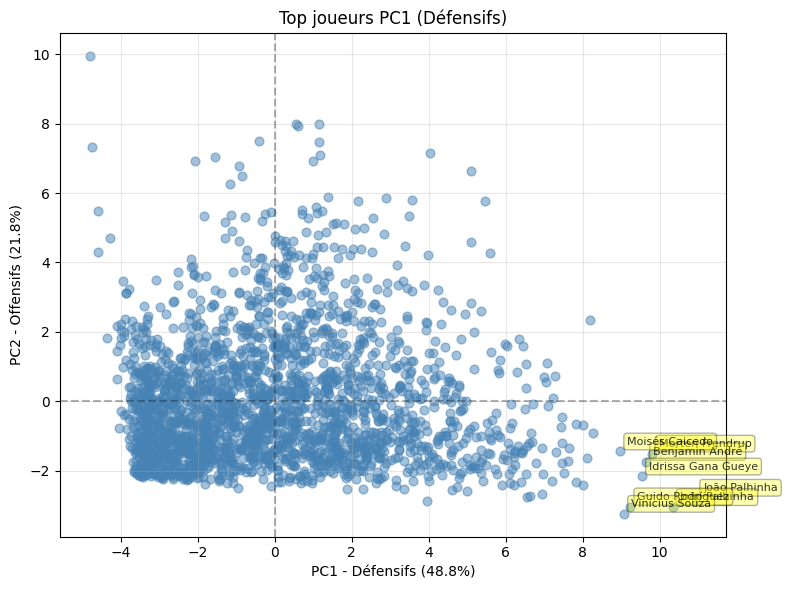

In [256]:
#Biplot top joueurs PC1
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                     alpha=0.5, s=40, c='steelblue')

top_players = df_results.nlargest(8, 'PC1')
for idx, row in top_players.iterrows():
    plt.annotate(row['Player'], 
                 (row['PC1'], row['PC2']),
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=8,
                 alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

plt.xlabel(f'PC1 - Défensifs ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 - Offensifs ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Top joueurs PC1 (Défensifs)')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

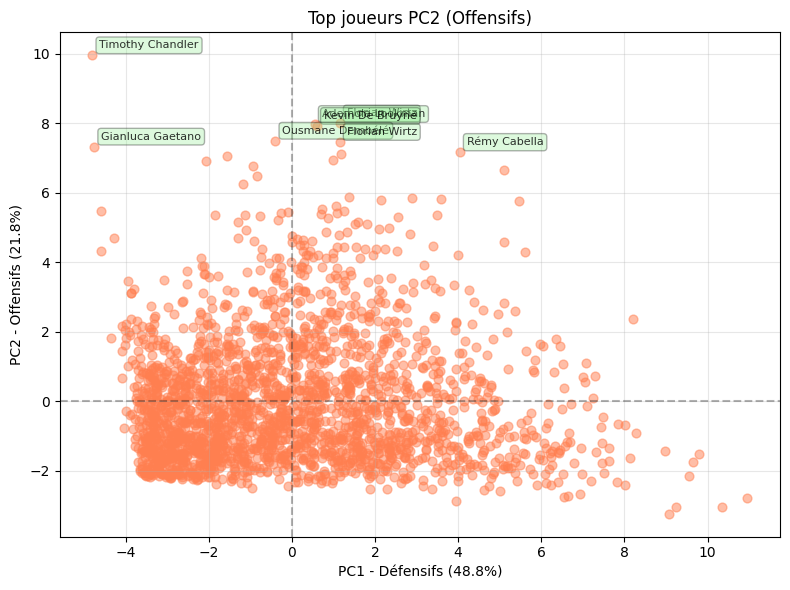

In [257]:
#Biplot top joueurs PC2
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                      alpha=0.5, s=40, c='coral')

top_scorers = df_results.nlargest(8, 'PC2')
for idx, row in top_scorers.iterrows():
    plt.annotate(row['Player'], 
                 (row['PC1'], row['PC2']),
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=8,
                 alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.3))

plt.xlabel(f'PC1 - Défensifs ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 - Offensifs ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Top joueurs PC2 (Offensifs)')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

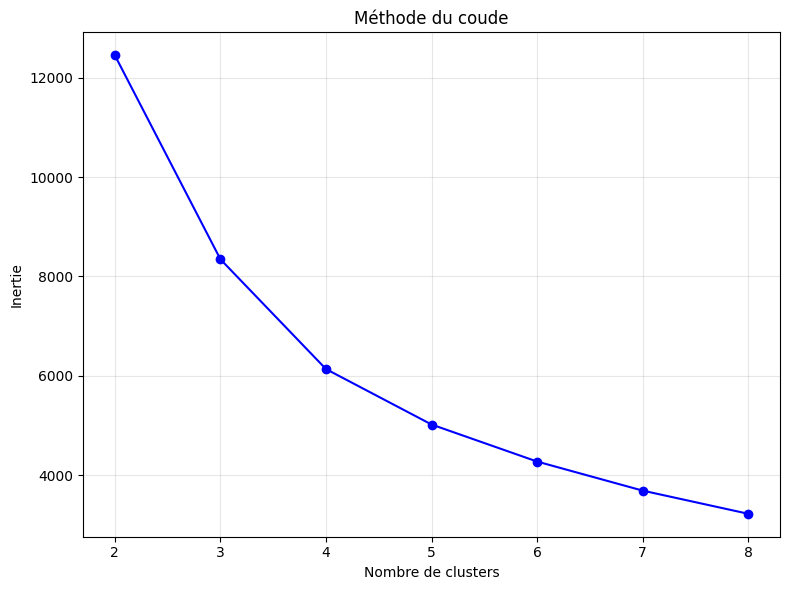

In [258]:
inertias = []
K_range = range(2, 9)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca2)
    inertias.append(kmeans.inertia_)


plt.figure(figsize=(8,6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

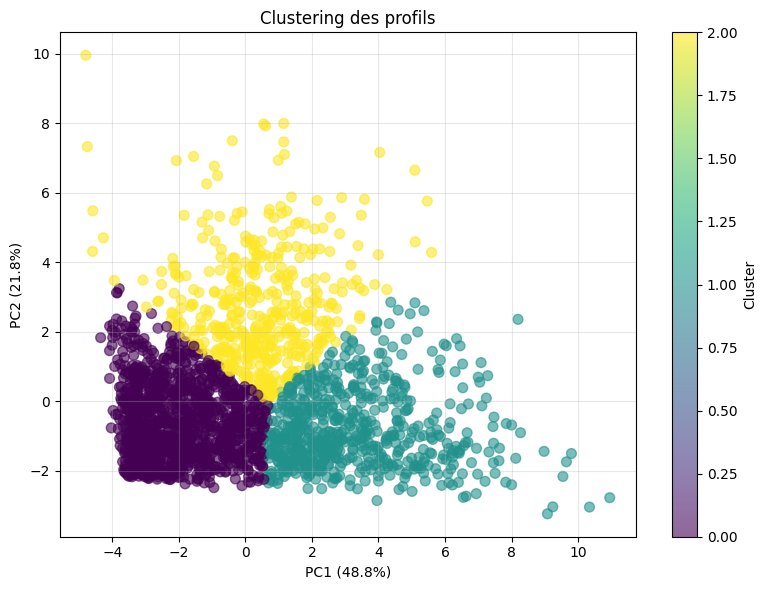

In [259]:
#Clustering K-means
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_results['Cluster'] = kmeans.fit_predict(X_pca2)

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                      c=df_results['Cluster'], 
                      cmap='viridis', 
                      alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Clustering des profils')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

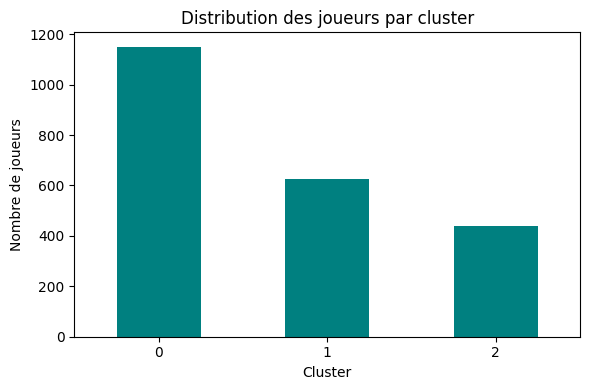

In [260]:
# Distribution des joueurs par cluster
plt.figure(figsize=(6,4))
df_results['Cluster'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Distribution des joueurs par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de joueurs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [261]:
print("\n🎯 Milieux défensifs (PC1 élevé, PC2 faible):")
creators = df_results[(df_results['PC1'] > df_results['PC1'].quantile(0.85)) & 
                      (df_results['PC2'] < df_results['PC2'].median())]
print(creators.nlargest(10,'PC1')[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())

print("\n⚽ Milieux offensifs (PC2 élevé, PC1 faible):")
scorers = df_results[(df_results['PC2'] > df_results['PC2'].quantile(0.85)) & 
                     (df_results['PC1'] < df_results['PC1'].median())]
print(scorers.nlargest(10,'PC2')[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())

print("\n⭐ Milieux centraux (PC1 et PC2 élevés):")
complete = df_results[(df_results['PC1'] > df_results['PC1'].quantile(0.90)) & 
                      (df_results['PC2'] > df_results['PC2'].quantile(0.90))]
print(complete[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())


🎯 Milieux défensifs (PC1 élevé, PC2 faible):
                  Player           Team            Comp        PC1       PC2
1267       João Palhinha         Fulham  Premier League  10.952087 -2.782019
537        João Palhinha         Fulham  Premier League  10.342186 -3.051661
985      Morten Frendrup          Genoa         Serie A   9.800326 -1.510397
31        Benjamin André          Lille         Ligue 1   9.649478 -1.748454
1727  Idrissa Gana Gueye        Everton  Premier League   9.544355 -2.169235
603      Guido Rodríguez          Betis         La Liga   9.241013 -3.044486
1391      Vinicius Souza  Sheffield Utd  Premier League   9.078995 -3.245774
1588      Moisés Caicedo        Chelsea  Premier League   8.978994 -1.448240
1124   Pierre Lees-Melou          Brest         Ligue 1   8.269890 -0.912052
1010          João Gomes         Wolves  Premier League   8.127428 -1.647345

⚽ Milieux offensifs (PC2 élevé, PC1 faible):
                    Player             Team            Comp  

In [262]:
cluster_names = {
    0: "Type 0",
    1: "Type 1", 
    2: "Type 2"
}

for cluster in range(optimal_k):
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster} - {cluster_names[cluster]}")
    print(f"{'='*70}")
    
    cluster_data = df_results[df_results['Cluster'] == cluster]
    print(f"Nombre de joueurs: {len(cluster_data)}")
    
    print(f"\nTop 5 joueurs:")
    print(cluster_data.nlargest(5, 'PC1')[['Player', 'Team', 'PC1', 'PC2']].to_string())
    
    print(f"\nMoyennes des features:")
    means = cluster_data[features_mid].mean()
    for feat, val in means.items():
        print(f"  {feat:15s}: {val:6.2f}")
    
    print(f"\nCaractéristiques PC:")
    print(f"  PC1 moyen: {cluster_data['PC1'].mean():6.2f} (défensifs)")
    print(f"  PC2 moyen: {cluster_data['PC2'].mean():6.2f} (offensifs)")


CLUSTER 0 - Type 0
Nombre de joueurs: 1150

Top 5 joueurs:
                   Player           Team       PC1       PC2
1968     Marshall Munetsi          Reims  0.673987 -0.131819
1568  Benjamin Bouchouari  Saint-Étienne  0.656064 -0.595630
1321      Amir Richardson          Reims  0.622737 -0.458945
2058      Elvis Rexhbeçaj       Augsburg  0.600798 -0.292724
13      Jean-Eudes Aholou     Strasbourg  0.582738 -0.621740

Moyennes des features:
  KP             :   8.61
  PrgC           :  13.45
  PrgR           :  27.27
  Gls/90         :   0.10
  Ast/90         :   0.09
  xG/90          :   0.12
  xAG/90         :   0.10
  Tkl            :  15.60
  TklW           :   9.07
  Tkl+Int        :  22.44
  Tkl Def 3rd    :   6.24
  Tkl Mid 3rd    :   7.10
  Blocks         :   9.59
  Int            :   6.84
  Clr            :   9.64

Caractéristiques PC:
  PC1 moyen:  -1.95 (défensifs)
  PC2 moyen:  -0.59 (offensifs)

CLUSTER 1 - Type 1
Nombre de joueurs: 625

Top 5 joueurs:
               